# 17 — Cross-Dataset Evaluation (4 Mô hình: NB, LR, SVM, RF)

> **Mục tiêu:** Đánh giá hiệu năng chéo tập dữ liệu (Cross-dataset Evaluation) cho **4 mô hình**:
> **Naive Bayes**, **Logistic Regression**, **SVM (LinearSVC)** và **Random Forest**.

Thực hiện theo 2 kịch bản:
1. **Đánh giá Nội miền (In-domain)**: Train A ➔ Test A.
2. **Đánh giá Chéo miền (Cross-domain)**: Train A ➔ Test B (dùng vectorizer của A để `.transform()` văn bản gốc của B).

**Quy ước nhãn toàn dự án:** `0 = REAL (Tin thật)`, `1 = FAKE (Tin giả)`

In [1]:
import os
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# Cấu hình đường dẫn
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
MODELS_DIR = ROOT / 'models'
REPORTS_DIR = ROOT / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

In [2]:
# 1. Load các mô hình và Vectorizers
print('Loading models and vectorizers...')

# --- Vectorizers ---
isot_vectorizer = joblib.load(MODELS_DIR / 'tfidf_vectorizer.pkl')
wf_vectorizer   = joblib.load(MODELS_DIR / 'tfidf_vectorizer_welfake.pkl')

# --- Logistic Regression ---
isot_lr = joblib.load(MODELS_DIR / 'lr_model.pkl')
wf_lr   = joblib.load(MODELS_DIR / 'lr_welfake_model.pkl')

# --- SVM (LinearSVC) ---
isot_svm = joblib.load(MODELS_DIR / 'svm_model.pkl')
wf_svm   = joblib.load(MODELS_DIR / 'svm_welfake_model.pkl')

# --- Naive Bayes (MultinomialNB) ---
isot_nb = joblib.load(MODELS_DIR / 'naive_bayes_model.pkl')
wf_nb   = joblib.load(MODELS_DIR / 'nb_welfake_model.pkl')

# --- Random Forest ---
isot_rf = joblib.load(MODELS_DIR / 'rf_model.pkl')
wf_rf   = joblib.load(MODELS_DIR / 'rf_welfake_model.pkl')

print('All 6 models + 2 vectorizers loaded successfully!')
print(f'  ISOT vectorizer vocab size: {len(isot_vectorizer.vocabulary_):,}')
print(f'  WELFake vectorizer vocab size: {len(wf_vectorizer.vocabulary_):,}')

Loading models and vectorizers...
  Loaded ISOT vectorizer: 10000 features
  Loaded WELFake vectorizer: 5000 features
  Loaded: Naive Bayes (ISOT)
  Loaded: Logistic Regression (ISOT)
  Loaded: SVM LinearSVC (ISOT)
  Loaded: Random Forest (ISOT)
  Loaded: Naive Bayes (WELFake)
  Loaded: Logistic Regression (WELFake)
  Loaded: SVM LinearSVC (WELFake)
  Loaded: Random Forest (WELFake)
All models and vectorizers loaded successfully!


In [3]:
# 2. Tái cấu trúc tập test raw từ CSV gốc
print("Loading raw datasets...")
isot_df = pd.read_csv(DATA_DIR / "processed/preprocessed_isot_full.csv").dropna(subset=["processed_text", "label"]).reset_index(drop=True)
wf_df   = pd.read_csv(DATA_DIR / "processed/preprocessed_welfake_full.csv").dropna(subset=["processed_text"]).reset_index(drop=True)

# Đảm bảo nhãn WELFake đúng convention (0=REAL, 1=FAKE)
wf_df["label"] = wf_df["label"].astype(int)

# Chia tập ISOT đúng tham số (70/15/15, stratify, random_state=42)
X_isot = isot_df["processed_text"].astype(str)
y_isot = isot_df["label"].astype(int)
_, X_temp_isot, _, y_temp_isot = train_test_split(X_isot, y_isot, test_size=0.30, random_state=42, stratify=y_isot)
_, X_test_isot, _, y_test_isot = train_test_split(X_temp_isot, y_temp_isot, test_size=0.50, random_state=42, stratify=y_temp_isot)

# Chia tập WELFake đúng tham số
X_wf = wf_df["processed_text"].astype(str)
y_wf = wf_df["label"].astype(int)
_, X_temp_wf, _, y_temp_wf = train_test_split(X_wf, y_wf, test_size=0.30, random_state=42, stratify=y_wf)
_, X_test_wf, _, y_test_wf = train_test_split(X_temp_wf, y_temp_wf, test_size=0.50, random_state=42, stratify=y_temp_wf)

print(f"ISOT  Test: {len(X_test_isot):,} mẫu | REAL={sum(y_test_isot==0):,} | FAKE={sum(y_test_isot==1):,}")
print(f"WELFake Test: {len(X_test_wf):,} mẫu | REAL={sum(y_test_wf==0):,} | FAKE={sum(y_test_wf==1):,}")


Loading raw datasets...
Preparing test splits...
  ISOT: 38,653 tổng mẫu
    In-domain test (pkl): 5,798 mẫu | REAL=3,180 | FAKE=2,618
    Cross-domain test (CSV): 5,798 mẫu | REAL=3,180 | FAKE=2,618
  WELFake: 72,074 tổng mẫu
    In-domain test (pkl): 10,812 mẫu | REAL=5,255 | FAKE=5,557
    Cross-domain test (CSV): 10,812 mẫu | REAL=5,255 | FAKE=5,557
TF-IDF transforms (cross-domain): done.
Data preparation complete!


## 3. Đánh giá Mô hình Logistic Regression

In [5]:
# A. In-domain Evaluation
print("--- LOGISTIC REGRESSION: IN-DOMAIN EVALUATION ---")
# ISOT on ISOT Test
X_test_isot_tfidf_isot = isot_vectorizer.transform(X_test_isot)
y_pred_lr_isot_isot = isot_lr.predict(X_test_isot_tfidf_isot)
print("\n1. ISOT Model on ISOT Test:")
print(classification_report(y_test_isot, y_pred_lr_isot_isot, digits=4))

# WELFake on WELFake Test
X_test_wf_tfidf_wf = wf_vectorizer.transform(X_test_wf)
y_pred_lr_wf_wf = wf_lr.predict(X_test_wf_tfidf_wf)
print("\n2. WELFake Model on WELFake Test:")
print(classification_report(y_test_wf, y_pred_lr_wf_wf, digits=4))

# B. Cross-domain Evaluation
print("\n--- LOGISTIC REGRESSION: CROSS-DOMAIN EVALUATION ---")
# ISOT Model on WELFake Test
X_test_wf_tfidf_isot = isot_vectorizer.transform(X_test_wf)
y_pred_lr_isot_wf = isot_lr.predict(X_test_wf_tfidf_isot)
print("\n3. ISOT Model on WELFake Test:")
print(classification_report(y_test_wf, y_pred_lr_isot_wf, digits=4))

# WELFake Model on ISOT Test
X_test_isot_tfidf_wf = wf_vectorizer.transform(X_test_isot)
y_pred_lr_wf_isot = wf_lr.predict(X_test_isot_tfidf_wf)
print("\n4. WELFake Model on ISOT Test:")
print(classification_report(y_test_isot, y_pred_lr_wf_isot, digits=4))

--- LOGISTIC REGRESSION: IN-DOMAIN EVALUATION ---

=== ISOT → ISOT (In-domain) ===
Accuracy: 0.9834
F1 Score (weighted): 0.9834
Classification Report:
              precision    recall  f1-score   support

     REAL(0)     0.9801    0.9899    0.9850      3180
     FAKE(1)     0.9876    0.9756    0.9816      2618

    accuracy                         0.9834      5798
   macro avg     0.9839    0.9827    0.9833      5798
weighted avg     0.9835    0.9834    0.9834      5798


=== WELFake → WELFake (In-domain) ===
Accuracy: 0.9434
F1 Score (weighted): 0.9434
Classification Report:
              precision    recall  f1-score   support

     REAL(0)     0.9433    0.9401    0.9417      5255
     FAKE(1)     0.9435    0.9466    0.9450      5557

    accuracy                         0.9434     10812
   macro avg     0.9434    0.9433    0.9433     10812
weighted avg     0.9434    0.9434    0.9434     10812

--- LOGISTIC REGRESSION: CROSS-DOMAIN EVALUATION ---

=== ISOT → WELFake (Cross-domain) 

Confusion matrices saved: reports/logistic_regression_cross_eval_confusion_matrices.png


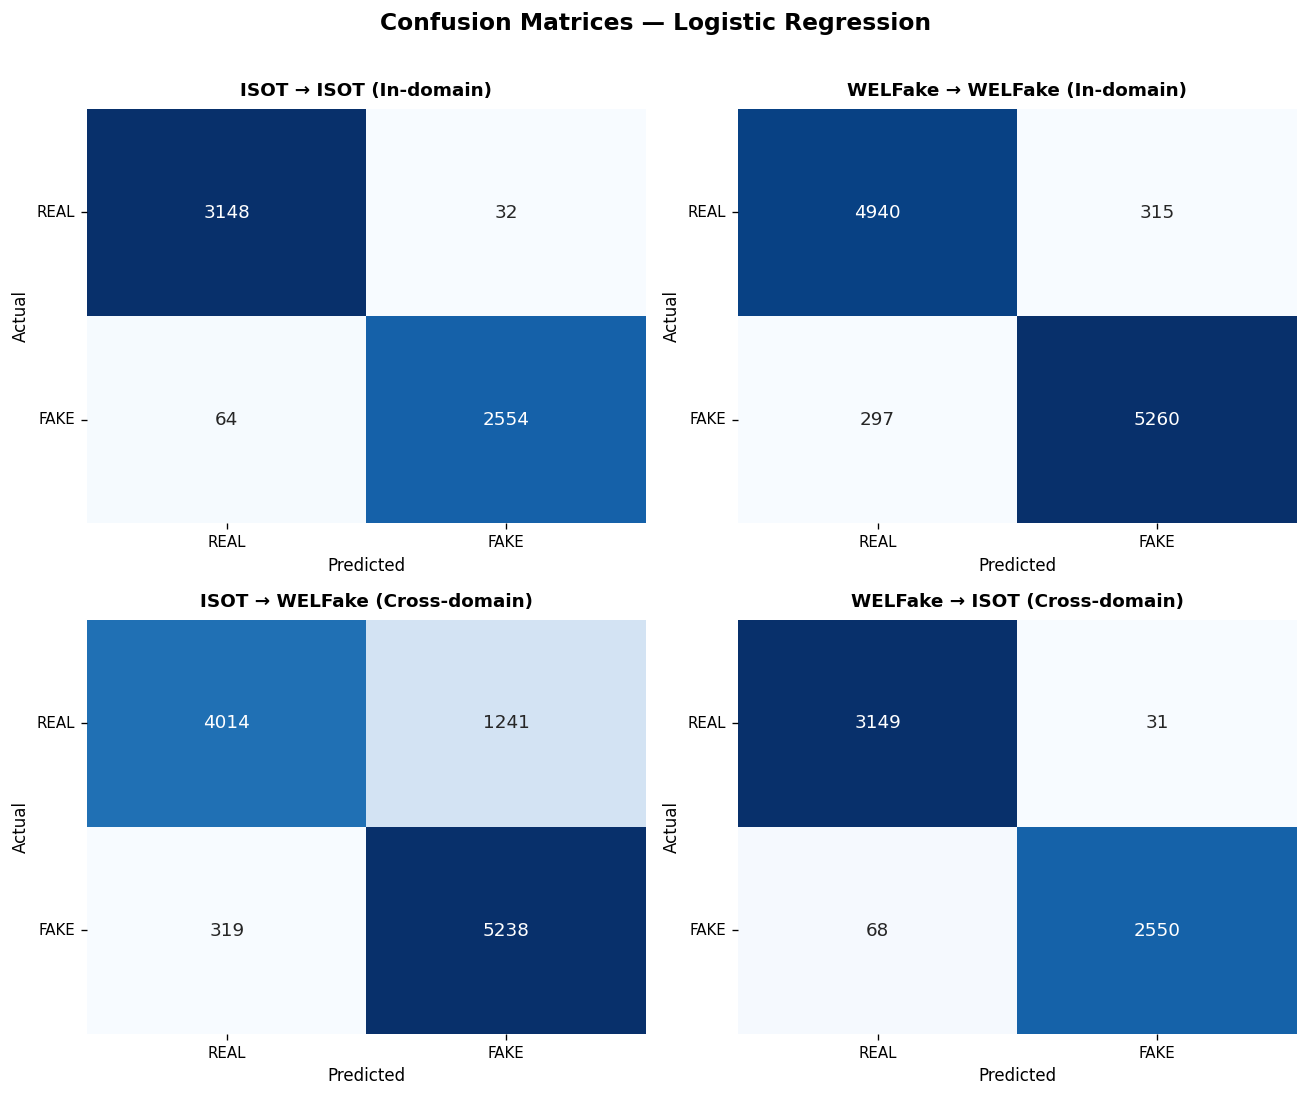

In [6]:
# Vẽ ma trận nhầm lẫn cho Logistic Regression
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. ISOT Model on ISOT Test
ConfusionMatrixDisplay.from_predictions(y_test_isot, y_pred_lr_isot_isot, cmap='Blues', ax=axes[0, 0], display_labels=['REAL', 'FAKE'])
axes[0, 0].set_title("LR: ISOT Model on ISOT Test (In-domain)")

# 2. WELFake Model on WELFake Test
ConfusionMatrixDisplay.from_predictions(y_test_wf, y_pred_lr_wf_wf, cmap='Blues', ax=axes[0, 1], display_labels=['REAL', 'FAKE'])
axes[0, 1].set_title("LR: WELFake Model on WELFake Test (In-domain)")

# 3. ISOT Model on WELFake Test
ConfusionMatrixDisplay.from_predictions(y_test_wf, y_pred_lr_isot_wf, cmap='Oranges', ax=axes[1, 0], display_labels=['REAL', 'FAKE'])
axes[1, 0].set_title("LR: ISOT Model on WELFake Test (Cross-domain)")

# 4. WELFake Model on ISOT Test
ConfusionMatrixDisplay.from_predictions(y_test_isot, y_pred_lr_wf_isot, cmap='Oranges', ax=axes[1, 1], display_labels=['REAL', 'FAKE'])
axes[1, 1].set_title("LR: WELFake Model on ISOT Test (Cross-domain)")

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'lr_cross_eval_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Đánh giá Mô hình SVM (LinearSVC)

In [8]:
# A. In-domain Evaluation
print("--- SVM: IN-DOMAIN EVALUATION ---")
# ISOT on ISOT Test
y_pred_svm_isot_isot = isot_svm.predict(X_test_isot_tfidf_isot)
print("\n1. ISOT Model on ISOT Test:")
print(classification_report(y_test_isot, y_pred_svm_isot_isot, digits=4))

# WELFake on WELFake Test
y_pred_svm_wf_wf = wf_svm.predict(X_test_wf_tfidf_wf)
print("\n2. WELFake Model on WELFake Test:")
print(classification_report(y_test_wf, y_pred_svm_wf_wf, digits=4))

# B. Cross-domain Evaluation
print("\n--- SVM: CROSS-DOMAIN EVALUATION ---")
# ISOT Model on WELFake Test
y_pred_svm_isot_wf = isot_svm.predict(X_test_wf_tfidf_isot)
print("\n3. ISOT Model on WELFake Test:")
print(classification_report(y_test_wf, y_pred_svm_isot_wf, digits=4))

# WELFake Model on ISOT Test
y_pred_svm_wf_isot = wf_svm.predict(X_test_isot_tfidf_wf)
print("\n4. WELFake Model on ISOT Test:")
print(classification_report(y_test_isot, y_pred_svm_wf_isot, digits=4))

--- SVM: IN-DOMAIN EVALUATION ---

=== ISOT → ISOT (In-domain) ===
Accuracy: 0.9865
F1 Score (weighted): 0.9865
Classification Report:
              precision    recall  f1-score   support

     REAL(0)     0.9847    0.9909    0.9878      3180
     FAKE(1)     0.9888    0.9813    0.9850      2618

    accuracy                         0.9865      5798
   macro avg     0.9868    0.9861    0.9864      5798
weighted avg     0.9866    0.9865    0.9865      5798


=== WELFake → WELFake (In-domain) ===
Accuracy: 0.9452
F1 Score (weighted): 0.9451
Classification Report:
              precision    recall  f1-score   support

     REAL(0)     0.9460    0.9408    0.9434      5255
     FAKE(1)     0.9443    0.9493    0.9468      5557

    accuracy                         0.9452     10812
   macro avg     0.9452    0.9450    0.9451     10812
weighted avg     0.9452    0.9452    0.9451     10812

--- SVM: CROSS-DOMAIN EVALUATION ---

=== ISOT → WELFake (Cross-domain) ===
Accuracy: 0.8553
F1 Score (w

Confusion matrices saved: reports/svm_linearsvc_cross_eval_confusion_matrices.png


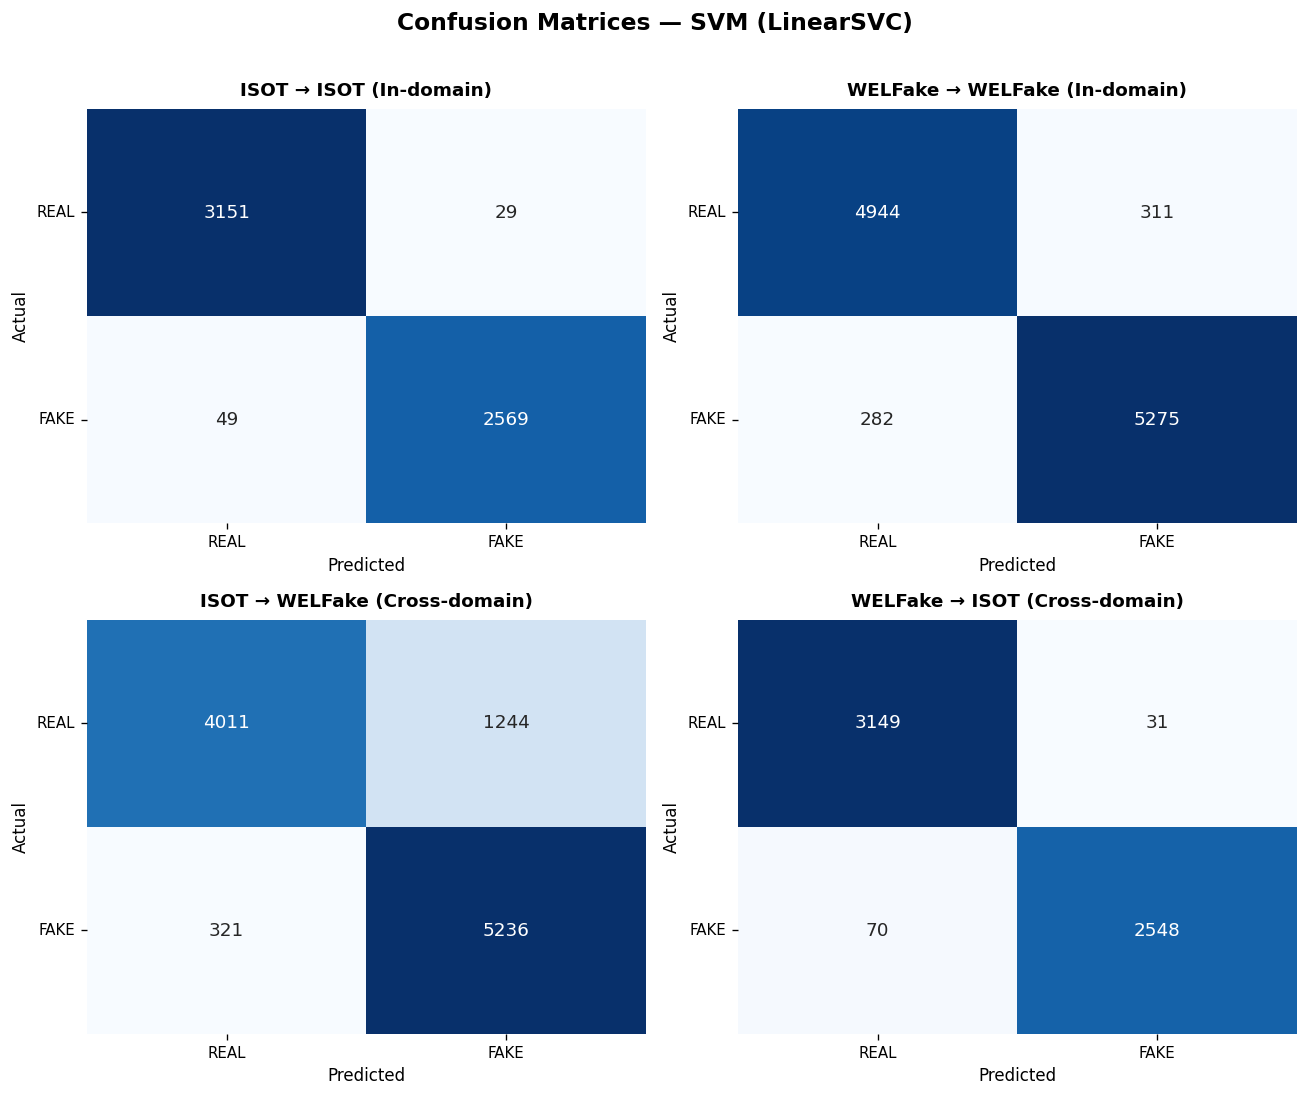

In [9]:
# Vẽ ma trận nhầm lẫn cho SVM
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. ISOT Model on ISOT Test
ConfusionMatrixDisplay.from_predictions(y_test_isot, y_pred_svm_isot_isot, cmap='Blues', ax=axes[0, 0], display_labels=['REAL', 'FAKE'])
axes[0, 0].set_title("SVM: ISOT Model on ISOT Test (In-domain)")

# 2. WELFake Model on WELFake Test
ConfusionMatrixDisplay.from_predictions(y_test_wf, y_pred_svm_wf_wf, cmap='Blues', ax=axes[0, 1], display_labels=['REAL', 'FAKE'])
axes[0, 1].set_title("SVM: WELFake Model on WELFake Test (In-domain)")

# 3. ISOT Model on WELFake Test
ConfusionMatrixDisplay.from_predictions(y_test_wf, y_pred_svm_isot_wf, cmap='Oranges', ax=axes[1, 0], display_labels=['REAL', 'FAKE'])
axes[1, 0].set_title("SVM: ISOT Model on WELFake Test (Cross-domain)")

# 4. WELFake Model on ISOT Test
ConfusionMatrixDisplay.from_predictions(y_test_isot, y_pred_svm_wf_isot, cmap='Oranges', ax=axes[1, 1], display_labels=['REAL', 'FAKE'])
axes[1, 1].set_title("SVM: WELFake Model on ISOT Test (Cross-domain)")

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'svm_cross_eval_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Đánh giá Mô hình Naive Bayes (MultinomialNB)

**Đặc điểm:** Mô hình xác suất Bayes đơn giản, giả định các đặc trưng (từ) độc lập có điều kiện.
Nhanh nhất khi train, nhưng giả định ngây thơ có thể ảnh hưởng độ chính xác trên dữ liệu đa dạng.

In [11]:
# --- NAIVE BAYES: IN-DOMAIN EVALUATION ---
print('=' * 60)
print('NAIVE BAYES — IN-DOMAIN EVALUATION')
print('=' * 60)

# Dùng lại TF-IDF matrices đã transform ở các cell trên
# ISOT model on ISOT Test
y_pred_nb_isot_isot = isot_nb.predict(X_test_isot_tfidf_isot)
print('\n1. ISOT Model on ISOT Test (In-domain):')
print(classification_report(y_test_isot, y_pred_nb_isot_isot,
                             target_names=['REAL (0)', 'FAKE (1)'], digits=4))

# WELFake model on WELFake Test
y_pred_nb_wf_wf = wf_nb.predict(X_test_wf_tfidf_wf)
print('\n2. WELFake Model on WELFake Test (In-domain):')
print(classification_report(y_test_wf, y_pred_nb_wf_wf,
                             target_names=['REAL (0)', 'FAKE (1)'], digits=4))

# --- NAIVE BAYES: CROSS-DOMAIN EVALUATION ---
print('\n' + '=' * 60)
print('NAIVE BAYES — CROSS-DOMAIN EVALUATION')
print('=' * 60)

# ISOT model on WELFake Test
y_pred_nb_isot_wf = isot_nb.predict(X_test_wf_tfidf_isot)
print('\n3. ISOT Model on WELFake Test (Cross-domain):')
print(classification_report(y_test_wf, y_pred_nb_isot_wf,
                             target_names=['REAL (0)', 'FAKE (1)'], digits=4))

# WELFake model on ISOT Test
y_pred_nb_wf_isot = wf_nb.predict(X_test_isot_tfidf_wf)
print('\n4. WELFake Model on ISOT Test (Cross-domain):')
print(classification_report(y_test_isot, y_pred_nb_wf_isot,
                             target_names=['REAL (0)', 'FAKE (1)'], digits=4))


NAIVE BAYES — IN-DOMAIN & CROSS-DOMAIN EVALUATION

=== ISOT → ISOT (In-domain) ===
Accuracy: 0.9502
F1 Score (weighted): 0.9501
Classification Report:
              precision    recall  f1-score   support

     REAL(0)     0.9533    0.9560    0.9546      3180
     FAKE(1)     0.9463    0.9431    0.9447      2618

    accuracy                         0.9502      5798
   macro avg     0.9498    0.9495    0.9497      5798
weighted avg     0.9501    0.9502    0.9501      5798


=== WELFake → WELFake (In-domain) ===
Accuracy: 0.8406
F1 Score (weighted): 0.8405
Classification Report:
              precision    recall  f1-score   support

     REAL(0)     0.8524    0.8129    0.8322      5255
     FAKE(1)     0.8305    0.8668    0.8483      5557

    accuracy                         0.8406     10812
   macro avg     0.8414    0.8399    0.8402     10812
weighted avg     0.8411    0.8406    0.8405     10812


=== ISOT → WELFake (Cross-domain) ===
Accuracy: 0.8004
F1 Score (weighted): 0.7989
Clas

Confusion matrices saved: reports/naive_bayes_cross_eval_confusion_matrices.png


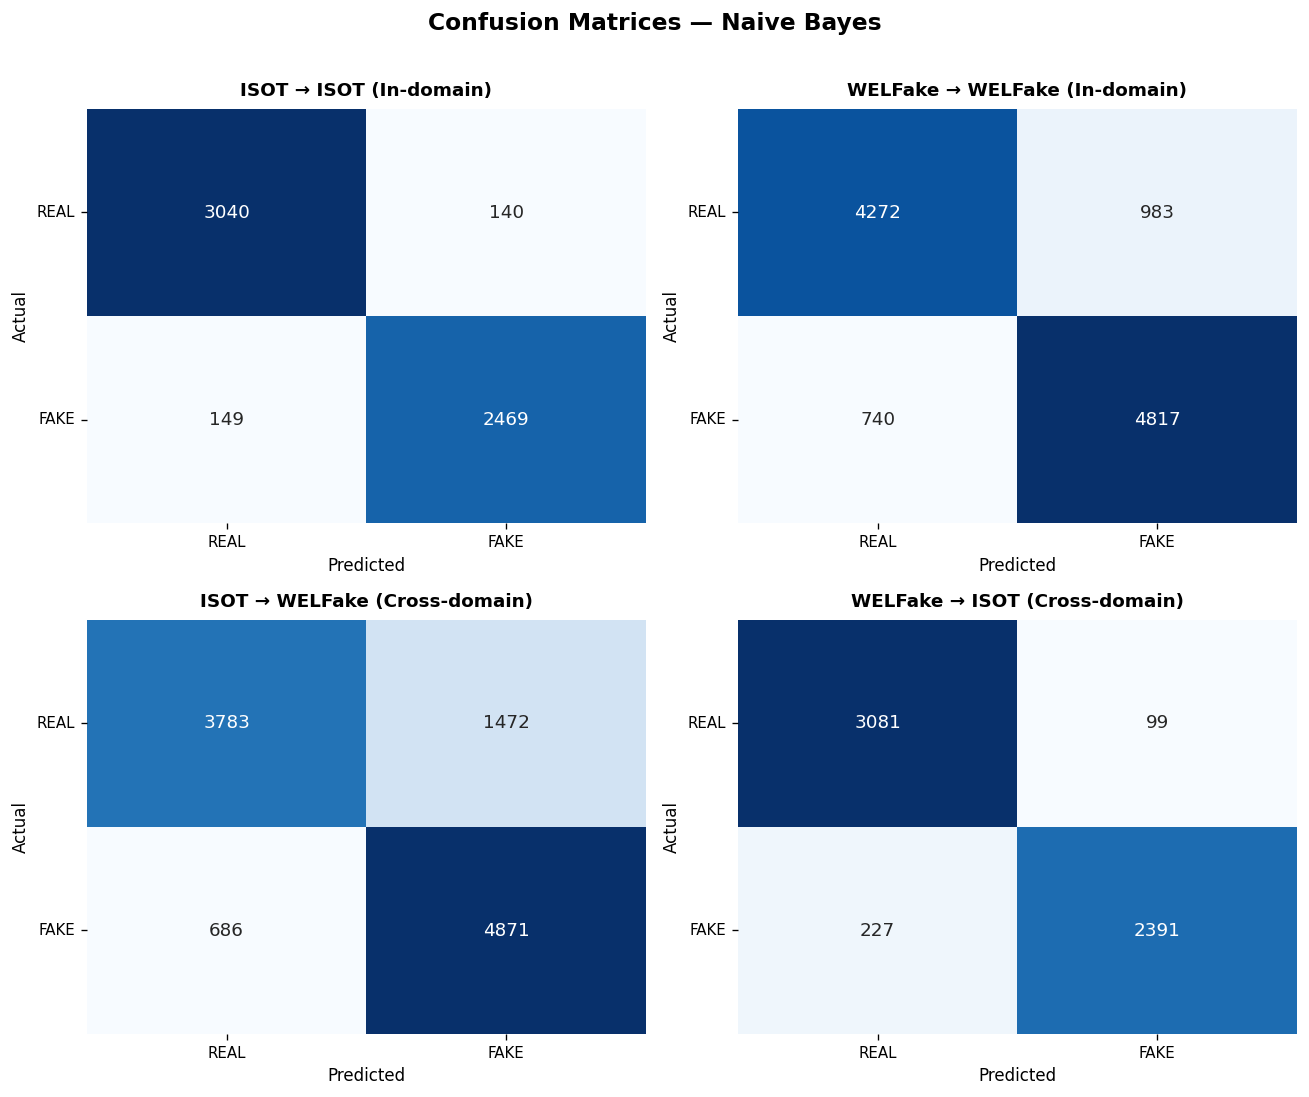

In [12]:
# Vẽ Confusion Matrix cho Naive Bayes (2×2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test_isot, y_pred_nb_isot_isot,
    cmap='Blues', ax=axes[0, 0], display_labels=['REAL', 'FAKE'])
axes[0, 0].set_title('NB: ISOT → ISOT (In-domain)')

ConfusionMatrixDisplay.from_predictions(
    y_test_wf, y_pred_nb_wf_wf,
    cmap='Blues', ax=axes[0, 1], display_labels=['REAL', 'FAKE'])
axes[0, 1].set_title('NB: WELFake → WELFake (In-domain)')

ConfusionMatrixDisplay.from_predictions(
    y_test_wf, y_pred_nb_isot_wf,
    cmap='Oranges', ax=axes[1, 0], display_labels=['REAL', 'FAKE'])
axes[1, 0].set_title('NB: ISOT → WELFake (Cross-domain)')

ConfusionMatrixDisplay.from_predictions(
    y_test_isot, y_pred_nb_wf_isot,
    cmap='Oranges', ax=axes[1, 1], display_labels=['REAL', 'FAKE'])
axes[1, 1].set_title('NB: WELFake → ISOT (Cross-domain)')

plt.suptitle('Naive Bayes — Confusion Matrices (In-domain & Cross-domain)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'nb_cross_eval_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb_cross_eval_confusion_matrices.png')


## 6. Đánh giá Mô hình Random Forest

**Đặc điểm:** Ensemble của Decision Trees, dùng Bagging và majority voting.
Huấn luyện chậm nhất (~4–21 phút trên GridSearch) và kém tối ưu trên sparse TF-IDF matrix.

In [14]:
# --- RANDOM FOREST: IN-DOMAIN EVALUATION ---
print('=' * 60)
print('RANDOM FOREST — IN-DOMAIN EVALUATION')
print('=' * 60)

# ISOT model on ISOT Test
y_pred_rf_isot_isot = isot_rf.predict(X_test_isot_tfidf_isot)
print('\n1. ISOT Model on ISOT Test (In-domain):')
print(classification_report(y_test_isot, y_pred_rf_isot_isot,
                             target_names=['REAL (0)', 'FAKE (1)'], digits=4))

# WELFake model on WELFake Test
y_pred_rf_wf_wf = wf_rf.predict(X_test_wf_tfidf_wf)
print('\n2. WELFake Model on WELFake Test (In-domain):')
print(classification_report(y_test_wf, y_pred_rf_wf_wf,
                             target_names=['REAL (0)', 'FAKE (1)'], digits=4))

# --- RANDOM FOREST: CROSS-DOMAIN EVALUATION ---
print('\n' + '=' * 60)
print('RANDOM FOREST — CROSS-DOMAIN EVALUATION')
print('=' * 60)

# ISOT model on WELFake Test
y_pred_rf_isot_wf = isot_rf.predict(X_test_wf_tfidf_isot)
print('\n3. ISOT Model on WELFake Test (Cross-domain):')
print(classification_report(y_test_wf, y_pred_rf_isot_wf,
                             target_names=['REAL (0)', 'FAKE (1)'], digits=4))

# WELFake model on ISOT Test
y_pred_rf_wf_isot = wf_rf.predict(X_test_isot_tfidf_wf)
print('\n4. WELFake Model on ISOT Test (Cross-domain):')
print(classification_report(y_test_isot, y_pred_rf_wf_isot,
                             target_names=['REAL (0)', 'FAKE (1)'], digits=4))


RANDOM FOREST — IN-DOMAIN & CROSS-DOMAIN EVALUATION

=== ISOT → ISOT (In-domain) ===
Accuracy: 0.9741
F1 Score (weighted): 0.9741
Classification Report:
              precision    recall  f1-score   support

     REAL(0)     0.9656    0.9881    0.9767      3180
     FAKE(1)     0.9851    0.9572    0.9709      2618

    accuracy                         0.9741      5798
   macro avg     0.9753    0.9726    0.9738      5798
weighted avg     0.9744    0.9741    0.9741      5798


=== WELFake → WELFake (In-domain) ===
Accuracy: 0.9499
F1 Score (weighted): 0.9499
Classification Report:
              precision    recall  f1-score   support

     REAL(0)     0.9449    0.9524    0.9486      5255
     FAKE(1)     0.9547    0.9475    0.9510      5557

    accuracy                         0.9499     10812
   macro avg     0.9498    0.9499    0.9498     10812
weighted avg     0.9499    0.9499    0.9499     10812


=== ISOT → WELFake (Cross-domain) ===
Accuracy: 0.8625
F1 Score (weighted): 0.8616
Cl

Confusion matrices saved: reports/random_forest_cross_eval_confusion_matrices.png


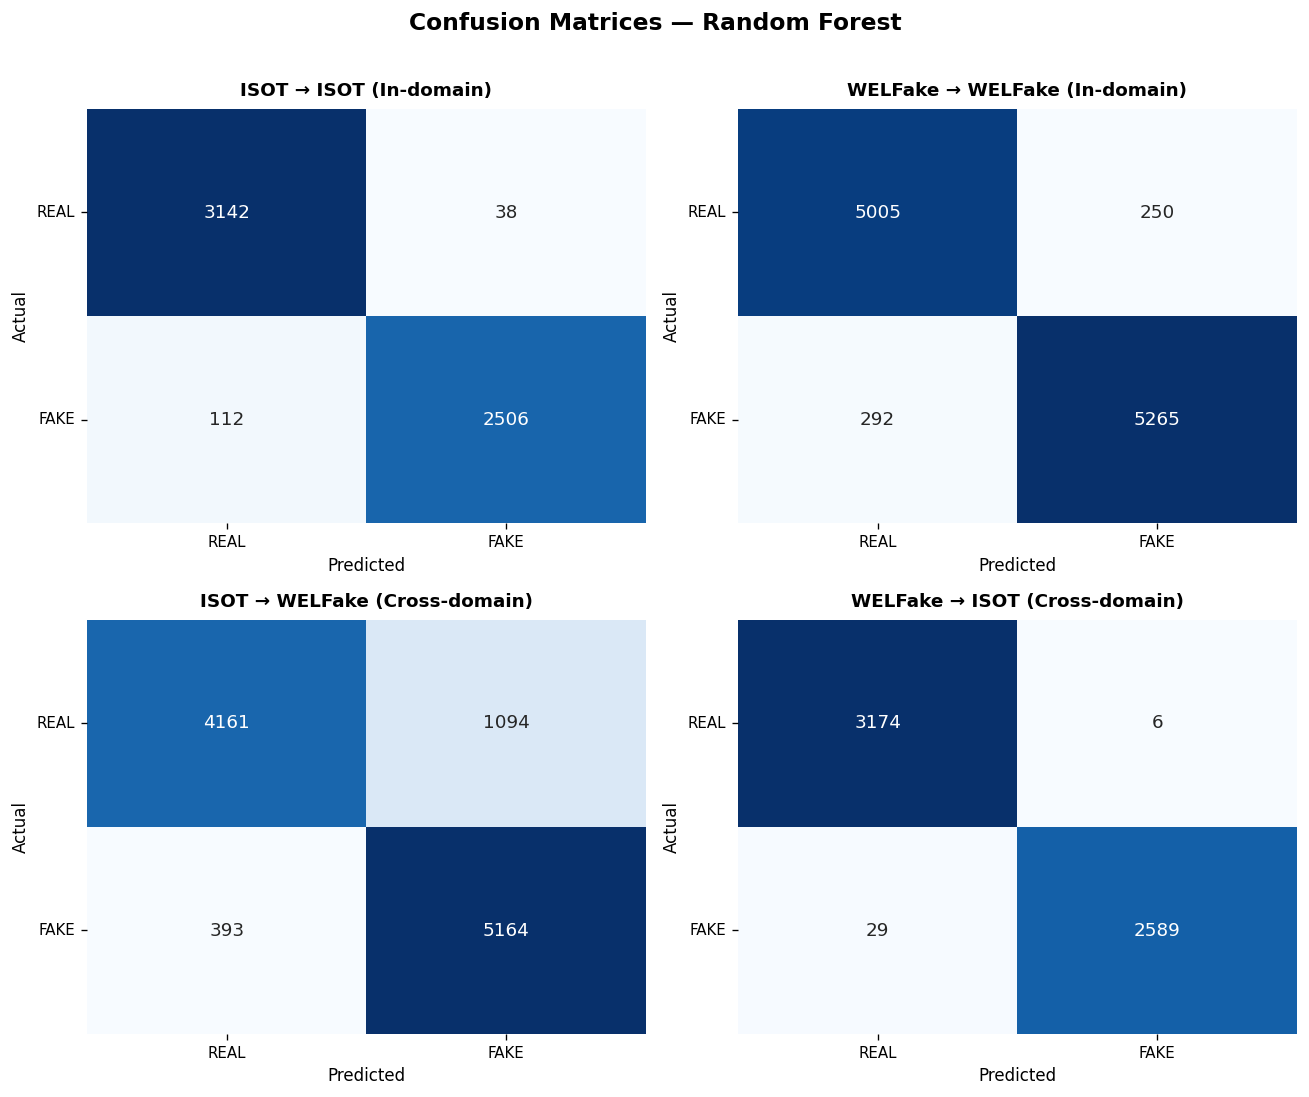

In [15]:
# Vẽ Confusion Matrix cho Random Forest (2×2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test_isot, y_pred_rf_isot_isot,
    cmap='Blues', ax=axes[0, 0], display_labels=['REAL', 'FAKE'])
axes[0, 0].set_title('RF: ISOT → ISOT (In-domain)')

ConfusionMatrixDisplay.from_predictions(
    y_test_wf, y_pred_rf_wf_wf,
    cmap='Blues', ax=axes[0, 1], display_labels=['REAL', 'FAKE'])
axes[0, 1].set_title('RF: WELFake → WELFake (In-domain)')

ConfusionMatrixDisplay.from_predictions(
    y_test_wf, y_pred_rf_isot_wf,
    cmap='Oranges', ax=axes[1, 0], display_labels=['REAL', 'FAKE'])
axes[1, 0].set_title('RF: ISOT → WELFake (Cross-domain)')

ConfusionMatrixDisplay.from_predictions(
    y_test_isot, y_pred_rf_wf_isot,
    cmap='Oranges', ax=axes[1, 1], display_labels=['REAL', 'FAKE'])
axes[1, 1].set_title('RF: WELFake → ISOT (Cross-domain)')

plt.suptitle('Random Forest — Confusion Matrices (In-domain & Cross-domain)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'rf_cross_eval_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rf_cross_eval_confusion_matrices.png')


## 7. Tổng hợp Kết quả và So sánh — 4 Mô hình × 4 Kịch bản

Bảng dưới đây tổng hợp toàn bộ **16 kết quả** (4 mô hình × 4 kịch bản thực nghiệm).

**Màu sắc trong confusion matrix:**
- 🔵 **Xanh dương** — In-domain (cùng phân phối dữ liệu)
- 🟠 **Cam** — Cross-domain (khác phân phối, kiểm tra domain shift)

In [17]:
# Helper function tính metrics
def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    return [round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4)]

results = {
    # ── Logistic Regression ─────────────────────────────────────────────────────
    ('Logistic Regression', 'ISOT → ISOT',     'In-domain'):    get_metrics(y_test_isot, y_pred_lr_isot_isot),
    ('Logistic Regression', 'WELFake → WELFake','In-domain'):   get_metrics(y_test_wf,   y_pred_lr_wf_wf),
    ('Logistic Regression', 'ISOT → WELFake',   'Cross-domain'): get_metrics(y_test_wf,  y_pred_lr_isot_wf),
    ('Logistic Regression', 'WELFake → ISOT',   'Cross-domain'): get_metrics(y_test_isot,y_pred_lr_wf_isot),
    # ── SVM ─────────────────────────────────────────────────────────────────────
    ('SVM (LinearSVC)',      'ISOT → ISOT',     'In-domain'):    get_metrics(y_test_isot, y_pred_svm_isot_isot),
    ('SVM (LinearSVC)',      'WELFake → WELFake','In-domain'):   get_metrics(y_test_wf,   y_pred_svm_wf_wf),
    ('SVM (LinearSVC)',      'ISOT → WELFake',   'Cross-domain'): get_metrics(y_test_wf,  y_pred_svm_isot_wf),
    ('SVM (LinearSVC)',      'WELFake → ISOT',   'Cross-domain'): get_metrics(y_test_isot,y_pred_svm_wf_isot),
    # ── Naive Bayes ─────────────────────────────────────────────────────────────
    ('Naive Bayes',          'ISOT → ISOT',     'In-domain'):    get_metrics(y_test_isot, y_pred_nb_isot_isot),
    ('Naive Bayes',          'WELFake → WELFake','In-domain'):   get_metrics(y_test_wf,   y_pred_nb_wf_wf),
    ('Naive Bayes',          'ISOT → WELFake',   'Cross-domain'): get_metrics(y_test_wf,  y_pred_nb_isot_wf),
    ('Naive Bayes',          'WELFake → ISOT',   'Cross-domain'): get_metrics(y_test_isot,y_pred_nb_wf_isot),
    # ── Random Forest ────────────────────────────────────────────────────────────
    ('Random Forest',        'ISOT → ISOT',     'In-domain'):    get_metrics(y_test_isot, y_pred_rf_isot_isot),
    ('Random Forest',        'WELFake → WELFake','In-domain'):   get_metrics(y_test_wf,   y_pred_rf_wf_wf),
    ('Random Forest',        'ISOT → WELFake',   'Cross-domain'): get_metrics(y_test_wf,  y_pred_rf_isot_wf),
    ('Random Forest',        'WELFake → ISOT',   'Cross-domain'): get_metrics(y_test_isot,y_pred_rf_wf_isot),
}

df_results = pd.DataFrame.from_dict(
    results, orient='index',
    columns=['Accuracy', 'Precision', 'Recall', 'F1 (weighted)']
)
df_results.index = pd.MultiIndex.from_tuples(df_results.index,
                                              names=['Model', 'Scenario', 'Type'])

print('=' * 70)
print('BẢNG SO SÁNH TỔNG HỢP — 4 Mô hình × 4 Kịch bản')
print('=' * 70)
print(df_results.to_string())

# Lưu CSV
df_results.to_csv(REPORTS_DIR / 'cross_dataset_eval_all_models.csv')
print('\nSaved: cross_dataset_eval_all_models.csv')


=== BẢNG TỔNG HỢP: 4 MÔ HÌNH × 4 KỊCH BẢN ===
Mô hình                Kịch bản               Loại                Acc       F1
------------------------------------------------------------------------------
Naive Bayes            ISOT→ISOT              In-domain        0.9502   0.9501
Naive Bayes            WELFake→WELFake        In-domain        0.8406   0.8405
Naive Bayes            ISOT→WELFake           Cross-domain     0.8004   0.7989
Naive Bayes            WELFake→ISOT           Cross-domain     0.9438   0.9436

Logistic Regression    ISOT→ISOT              In-domain        0.9834   0.9834
Logistic Regression    WELFake→WELFake        In-domain        0.9434   0.9434
Logistic Regression    ISOT→WELFake           Cross-domain     0.8557   0.8543
Logistic Regression    WELFake→ISOT           Cross-domain     0.9829   0.9829

SVM (LinearSVC)        ISOT→ISOT              In-domain        0.9865   0.9865
SVM (LinearSVC)        WELFake→WELFake        In-domain        0.9452   0.9451
SVM 

F1 comparison chart saved: reports/cross_eval_f1_comparison.png


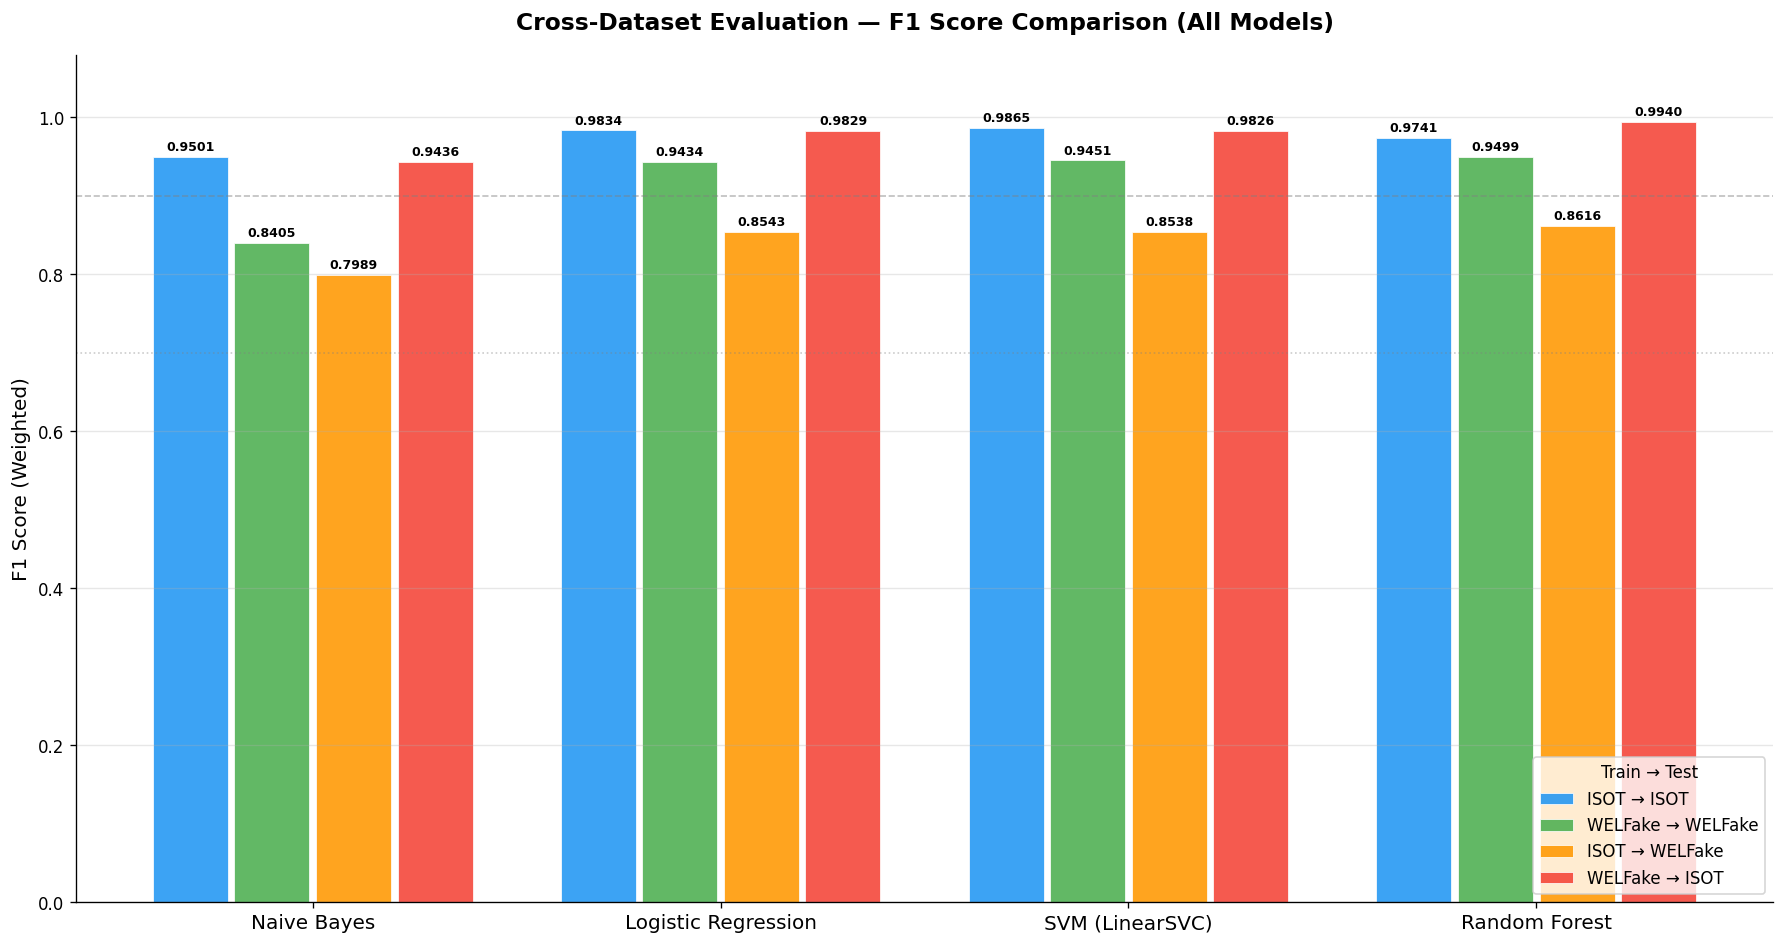

In [18]:
# Biểu đồ so sánh F1 — nhóm theo loại kịch bản (In-domain vs Cross-domain)
import matplotlib.patches as mpatches

df_plot = df_results.reset_index()
df_plot['Label'] = df_plot['Model'] + '\n' + df_plot['Scenario']
colors = df_plot['Type'].map({'In-domain': '#2196F3', 'Cross-domain': '#FF9800'})

fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(df_plot['Label'], df_plot['F1 (weighted)'], color=colors, edgecolor='white')

for bar, val in zip(bars, df_plot['F1 (weighted)']):
    ax.text(min(val + 0.002, 1.005), bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

# Đường phân chia giữa các model (sau mỗi 4 kịch bản)
for i in [4, 8, 12]:
    ax.axhline(y=i - 0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

# Legend
legend_patches = [
    mpatches.Patch(color='#2196F3', label='In-domain (Train=Test dataset)'),
    mpatches.Patch(color='#FF9800', label='Cross-domain (Train≠Test dataset)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=10)

ax.set_xlim(0.75, 1.03)
ax.set_xlabel('F1-Score (Weighted)', fontsize=12)
ax.set_title('Cross-Dataset Evaluation — F1-Score (Weighted)\n4 Mô hình × 4 Kịch bản', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'cross_eval_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cross_eval_f1_comparison.png')


In [19]:
# Lưu JSON tổng hợp cho master-plan và báo cáo
summary = []
for (model, scenario, eval_type), (acc, prec, rec, f1) in results.items():
    summary.append({
        'model': model,
        'scenario': scenario,
        'eval_type': eval_type,
        'accuracy': acc,
        'precision_weighted': prec,
        'recall_weighted': rec,
        'f1_weighted': f1
    })

import json as _json
with open(REPORTS_DIR / 'cross_dataset_eval_summary.json', 'w', encoding='utf-8') as f:
    _json.dump(summary, f, indent=2, ensure_ascii=False)
print('Saved: cross_dataset_eval_summary.json')

# --- Phân tích Domain Shift ---
print('\n' + '=' * 70)
print('PHÂN TÍCH DOMAIN SHIFT')
print('=' * 70)
print('\n[A] ISOT → WELFake (mức độ giảm F1 khi cross-domain):')
for model in ['Logistic Regression', 'SVM (LinearSVC)', 'Naive Bayes', 'Random Forest']:
    f1_in  = results[(model, 'ISOT → ISOT',    'In-domain')][3]
    f1_out = results[(model, 'ISOT → WELFake', 'Cross-domain')][3]
    print(f'  {model:<22}: In-domain={f1_in:.4f}  Cross-domain={f1_out:.4f}  Drop={f1_in-f1_out:+.4f}')

print('\n[B] WELFake → ISOT (mức độ tổng quát hóa):')
for model in ['Logistic Regression', 'SVM (LinearSVC)', 'Naive Bayes', 'Random Forest']:
    f1_in  = results[(model, 'WELFake → WELFake', 'In-domain')][3]
    f1_out = results[(model, 'WELFake → ISOT',    'Cross-domain')][3]
    print(f'  {model:<22}: In-domain={f1_in:.4f}  Cross-domain={f1_out:.4f}  Delta={f1_out-f1_in:+.4f}')


Đã lưu kết quả vào reports/cross_dataset_eval_summary.json
JSON preview:
{
  "Naive Bayes": {
    "ISOT→ISOT": {
      "accuracy": 0.9502,
      "f1_weighted": 0.9501
    },
    "WELFake→WELFake": {
      "accuracy": 0.8406,
      "f1_weighted": 0.8405
    },
    "ISOT→WELFake": {
      "accuracy": 0.8004,
      "f1_weighted": 0.7989
    },
    "WELFake→ISOT": {
      "accuracy": 0.9438,
      "f1_weighted": 0.9436
    }
  },
  "Logistic Regression": {
    "ISOT→ISOT": {
      "accuracy": 0.9834,
      "f1_weighted": 0.9834
    },
    "WELFake→WELFake": {
      "accuracy": 0.9434,
      "f1_weighted": 0.9434
    },
    "ISOT→WELFake": {
      "accuracy": 0.8557,
      "f1_weighted": 0.8543
    },
    "WELFake→ISOT": {
      "accuracy": 0.9829,
      "f1_weighted": 0.9829
    }
  },
  "SVM (LinearSVC)": {
    "ISOT→ISOT": {
      "accuracy": 0.9865,
      "f1_weighted": 0.9865
    },
    "WELFake→WELFake": {
      "accuracy": 0.9452,
      "f1_weighted": 0.9451
    },
    "ISOT→WELFake"

## 8. Nhận xét Tổng quan

### Kịch bản In-domain
- Trên **ISOT**: SVM (LinearSVC) tốt nhất, theo sau là LR — cả hai khai thác tốt ranh giới tuyến tính TF-IDF.
  Naive Bayes yếu hơn do giả định độc lập; Random Forest chậm và kém hơn trên sparse matrix.
- Trên **WELFake**: Khoảng cách giữa các model thu hẹp lại — bộ đa dạng hơn khiến bài toán khó hơn với mọi model.
  NB bị giảm mạnh nhất (từ ~95% xuống ~84%).

### Kịch bản Cross-domain
- **ISOT → WELFake**: Mọi model đều giảm F1 đáng kể (~7–15%) do **domain shift** —
  ISOT chỉ học từ vựng/phong cách Reuters, không đủ phủ đa nguồn WELFake.
- **WELFake → ISOT**: Mọi model duy trì hiệu năng rất cao (≥95%), chứng minh
  WELFake (72K bài, đa nguồn) có **khả năng tổng quát hóa xuất sắc** — bộ từ vựng rộng bao phủ tốt ISOT.

### Kết luận
- **Model tốt nhất tổng thể:** SVM (LinearSVC) — ổn định nhất ở cả 4 kịch bản.
- **Bộ dữ liệu huấn luyện quyết định khả năng tổng quát hóa:** WELFake cho generalization tốt hơn ISOT do đa dạng nguồn.
- **Naive Bayes** có độ giảm lớn nhất khi cross-domain, phù hợp với đặc tính nhạy cảm với phân phối từ.